In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,r2_score
import pickle
import joblib

In [2]:
df = pd.read_csv("Haul_Machines.csv")


In [3]:
print(df.head(5))
print(df.shape)

  Machine_ID  Hours_Operated  Breakdowns Last_Service_Date
0    Drill_1             922           3         1/25/2024
1    Truck_1            1871           2         5/11/2024
2    Drill_2            1346           1        12/19/2024
3    Truck_2            1954           2         7/15/2024
4    Drill_3             111           1         10/8/2024
(50, 4)


In [4]:
df.describe()

,Hours_Operated,Breakdowns
count,50.000000,50.00000
mean,1047.180000,2.08000
std,539.796322,1.70042
min,111.000000,0.00000
25%,624.750000,1.00000
50%,1095.000000,2.00000
75%,1452.750000,3.00000
max,1988.000000,6.00000


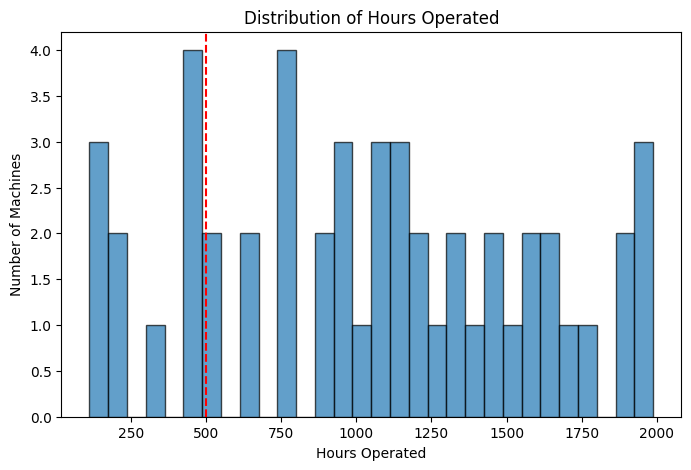

In [5]:
plt.figure(figsize=(8,5))
plt.hist(df["Hours_Operated"],bins=30,alpha=0.7,edgecolor="black")
plt.axvline(x=500,color="red",linestyle="--",label="500 Hours Threshold")
plt.xlabel("Hours Operated")
plt.ylabel("Number of Machines")
plt.title("Distribution of Hours Operated")
plt.legend
plt.show()

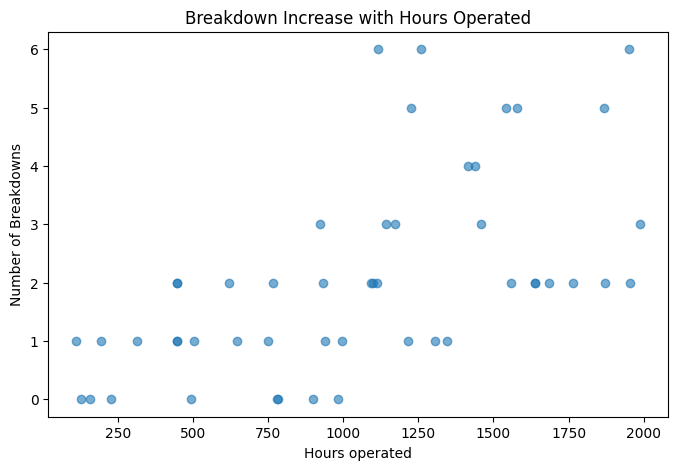

In [6]:
plt.figure(figsize=(8,5))
plt.scatter(df["Hours_Operated"],df["Breakdowns"],alpha=0.6)
plt.xlabel("Hours operated")
plt.ylabel("Number of Breakdowns")
plt.title("Breakdown Increase with Hours Operated")
plt.show()

In [7]:
df["Next_Failure_Hours"] = (2000 - df["Hours_Operated"]) - (df["Breakdowns"] * 50 + np.random.normal(0,100,size=len(df)))

In [8]:
print(df.head(5))

  Machine_ID  Hours_Operated  Breakdowns Last_Service_Date  Next_Failure_Hours
0    Drill_1             922           3         1/25/2024          798.819689
1    Truck_1            1871           2         5/11/2024           57.592324
2    Drill_2            1346           1        12/19/2024          713.228801
3    Truck_2            1954           2         7/15/2024         -150.394087
4    Drill_3             111           1         10/8/2024         1754.542547


In [9]:
x = df[["Hours_Operated","Breakdowns"]]
y = df["Next_Failure_Hours"]

In [10]:
x_train,x_test,y_train,y_test = train_test_split(x,y, test_size=0.2,random_state=42)

In [11]:
model = LinearRegression()
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [12]:
y_pred = model.predict(x_test)

In [13]:
print("\nModel Performance:")
print("Mean Absolute Error:",mean_absolute_error(y_test,y_pred))
print("R2 Score:",r2_score(y_test,y_pred))


Model Performance:
Mean Absolute Error: 58.51102819853795
R2 Score: 0.9811757566806445


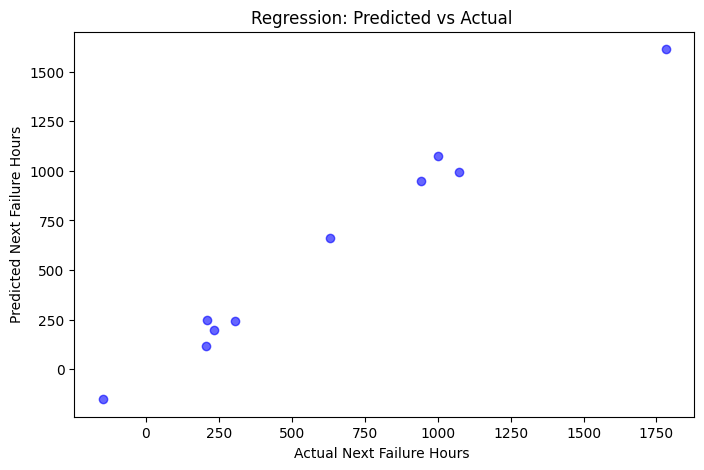

In [14]:
plt.figure(figsize=(8,5))
plt.scatter(y_test,y_pred,alpha=0.6,color="blue")
plt.xlabel("Actual Next Failure Hours ")
plt.ylabel("Predicted Next Failure Hours")
plt.title("Regression: Predicted vs Actual ")
plt.show()

C:\Users\DICKSON ANTIRI\AppData\Local\Temp\ipykernel_12012\1552004378.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  failure_rate = df.groupby("Hours_Bin")["Next_Failure_Hours"].mean()


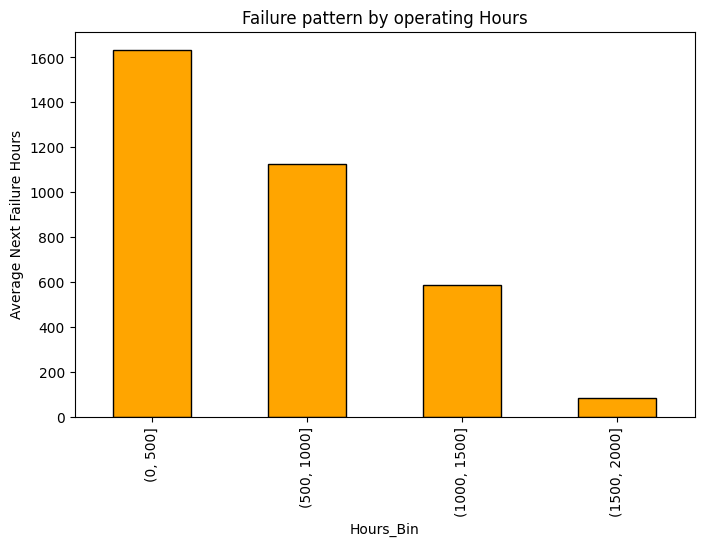

In [15]:
df["Hours_Bin"] = pd.cut(df["Hours_Operated"],bins= [0,500,1000,1500,2000])
failure_rate = df.groupby("Hours_Bin")["Next_Failure_Hours"].mean()

failure_rate.plot(kind= "bar",figsize=(8,5),color = "orange",edgecolor = "black")
plt.ylabel("Average Next Failure Hours")
plt.title("Failure pattern by operating Hours")
plt.show()

In [22]:
with open("Linear_regression_model.pkl","wb") as f:
    pickle.dump(model,f)